In [1]:
# Cell 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline

In [2]:
# Cell 2: Load the raw data with proper column names
# The UCI file has 15 attributes (A1-A15) + a class label, no header row,
# and missing values are marked as '?'
column_names = [f'A{i}' for i in range(1, 16)] + ['Class']

df = pd.read_csv('crx.data',
                  header=None,
                  names=column_names,
                  na_values='?')

df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,Class
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


In [3]:
# Cell 3: Save to CSV
df.to_csv('credit_approval.csv', index=False)
print("Saved. Shape:", df.shape)

Saved. Shape: (690, 16)


In [4]:
# Cell 4: Missing values overview + summary stats

# Data types and non-null counts for every column
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

# Summary statistics for the numeric columns only
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    object 
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      684 non-null    object 
 4   A5      684 non-null    object 
 5   A6      681 non-null    object 
 6   A7      681 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    int64  
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     677 non-null    float64
 14  A15     690 non-null    int64  
 15  Class   690 non-null    object 
dtypes: float64(4), int64(2), object(10)
memory usage: 86.4+ KB

Missing values per column:
A1       12
A2       12
A3        0
A4        6
A5        6
A6        9
A7        9
A8        0
A9        0
A10       0
A11       0
A12  

,A2,A3,A8,A11,A14,A15
count,678.000000,690.000000,690.000000,690.00000,677.000000,690.000000
mean,31.568171,4.758725,2.223406,2.40000,184.014771,1017.385507
std,11.957862,4.978163,3.346513,4.86294,173.806768,5210.102598
min,13.750000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,22.602500,1.000000,0.165000,0.00000,75.000000,0.000000
50%,28.460000,2.750000,1.000000,0.00000,160.000000,5.000000
75%,38.230000,7.207500,2.625000,3.00000,276.000000,395.500000
max,80.250000,28.000000,28.500000,67.00000,2000.000000,100000.000000


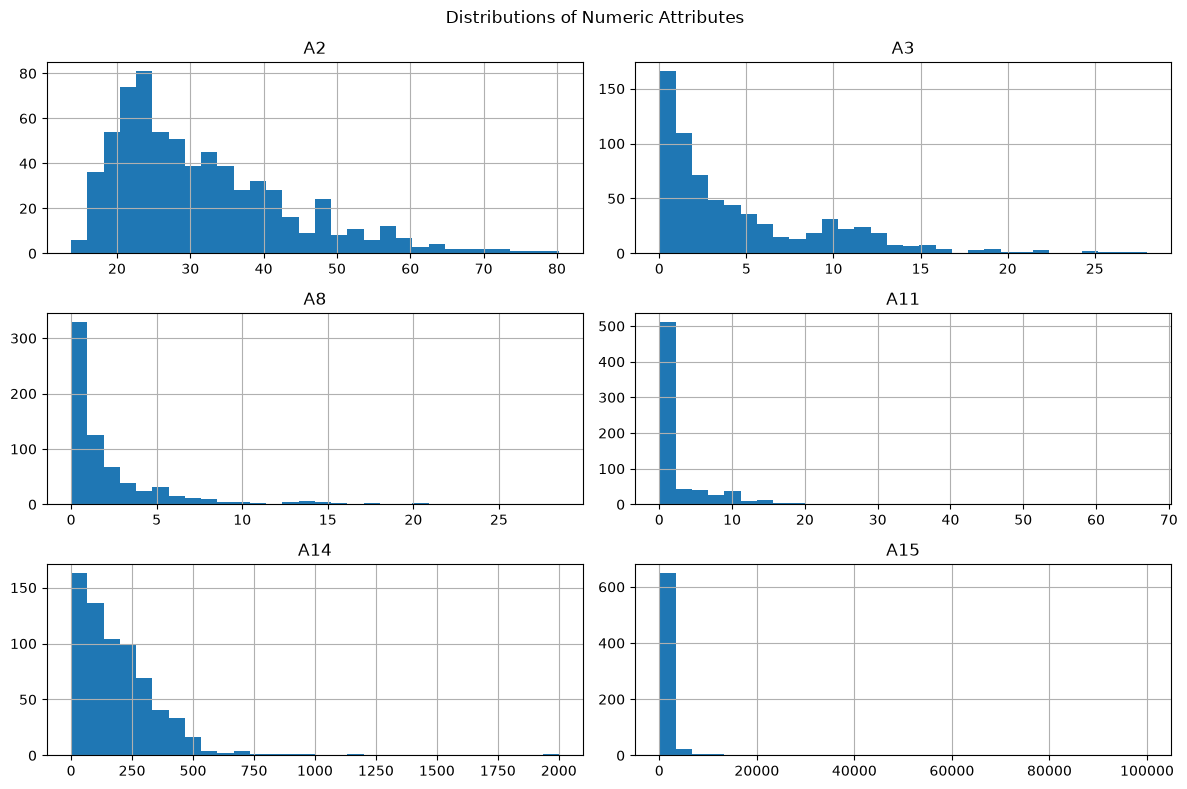

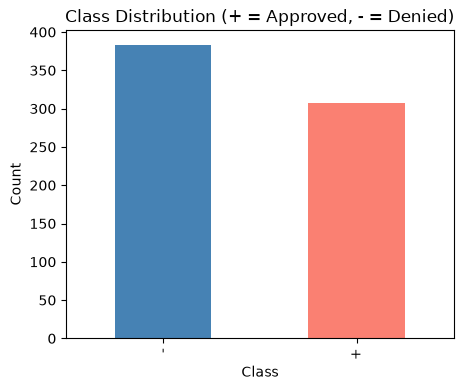

In [5]:
# Cell 5: Visualizations

# Separate numeric and categorical columns for convenience
numeric_cols = ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
categorical_cols = ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']

# Histograms for numeric columns
df[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Distributions of Numeric Attributes")
plt.tight_layout()
plt.show()

# Class balance (approved vs denied)
df['Class'].value_counts().plot(kind='bar', figsize=(5, 4), color=['steelblue', 'salmon'])
plt.title("Class Distribution (+ = Approved, - = Denied)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

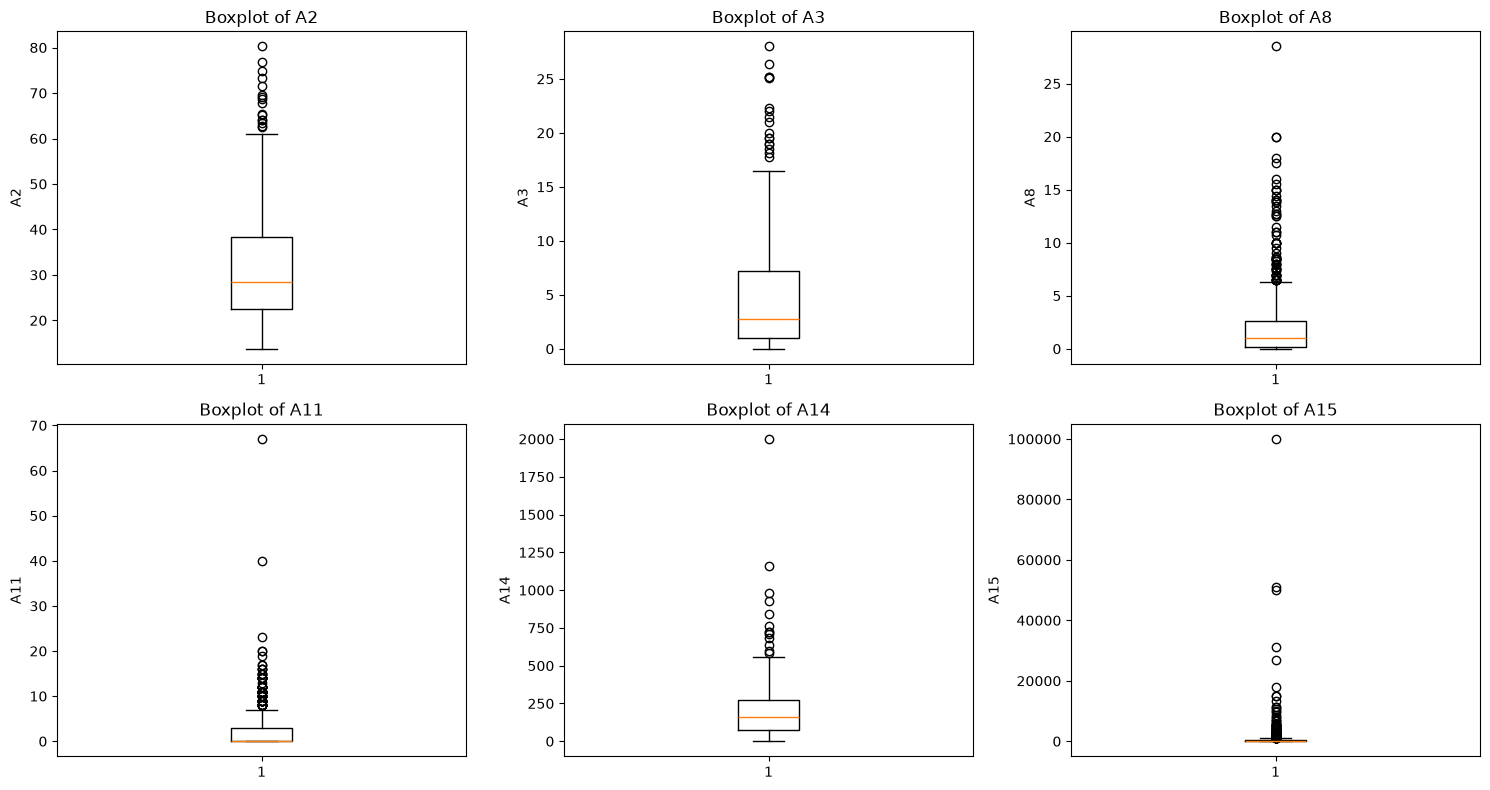

Outlier counts per numeric column (using 1.5 * IQR rule):

A2: 16 outliers (bounds: -0.84 to 61.67)
A3: 17 outliers (bounds: -8.31 to 16.52)
A8: 63 outliers (bounds: -3.52 to 6.31)
A11: 79 outliers (bounds: -4.50 to 7.50)
A14: 13 outliers (bounds: -226.50 to 577.50)
A15: 113 outliers (bounds: -593.25 to 988.75)


In [6]:
# Cell 6: Outlier detection with boxplots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# Also compute outlier counts numerically using the IQR method
print("Outlier counts per numeric column (using 1.5 * IQR rule):\n")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    print(f"{col}: {len(outliers)} outliers (bounds: {lower_bound:.2f} to {upper_bound:.2f})")

In [7]:
# Cell 7: Handle missing values
# Numeric columns with missing values: A2, A14 -> fill with median (robust to skew)
# Categorical columns with missing values: A1, A4, A5, A6, A7 -> fill with mode

numeric_missing = ['A2', 'A14']
categorical_missing = ['A1', 'A4', 'A5', 'A6', 'A7']

for col in numeric_missing:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_missing:
    df[col] = df[col].fillna(df[col].mode()[0])

# Confirm no missing values remain
print("Remaining missing values:\n", df.isnull().sum().sum())

Remaining missing values:
 0


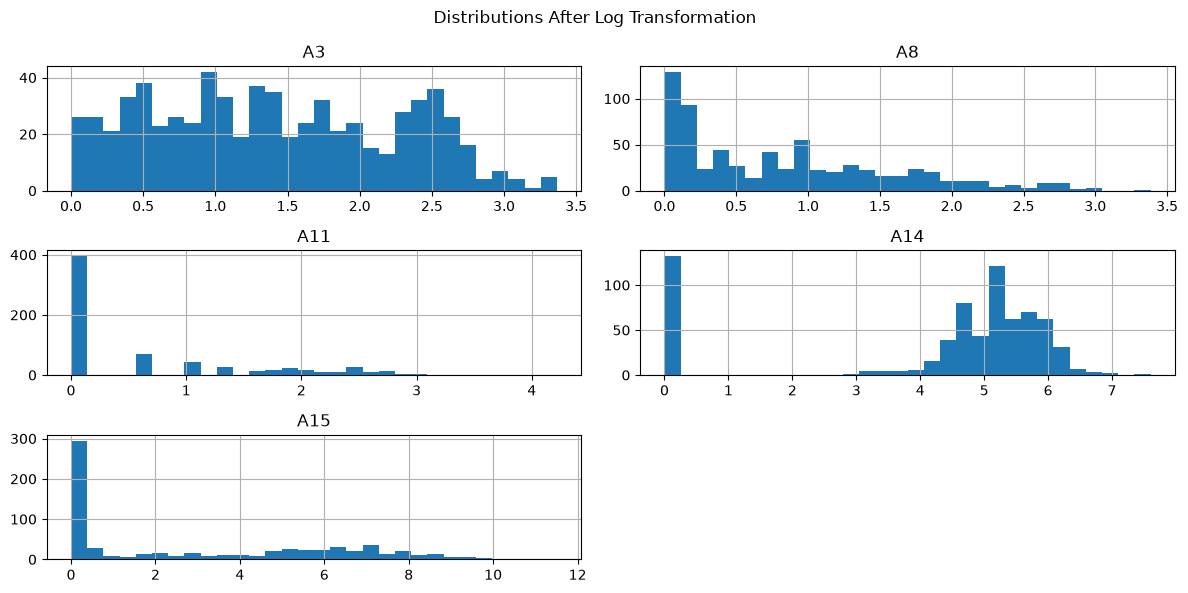

In [8]:
# Cell 8: Handle outliers via log transformation
# A3, A8, A11, A14, A15 are heavily right-skewed with many "outliers" by the IQR rule.
# Rather than deleting ~16% of rows (A15) or capping legitimate high values,
# we log-transform to compress the long tail while keeping every row.
# log1p (log(1+x)) is used instead of log() because these columns contain zeros,
# and log(0) is undefined.

skewed_cols = ['A3', 'A8', 'A11', 'A14', 'A15']

for col in skewed_cols:
    df[col] = np.log1p(df[col])

# Re-check the distributions after transformation
df[skewed_cols].hist(figsize=(12, 6), bins=30)
plt.suptitle("Distributions After Log Transformation")
plt.tight_layout()
plt.show()

In [9]:
# Quick check: how many categories does each categorical column have?
categorical_cols_all = ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']
for col in categorical_cols_all:
    print(f"{col}: {df[col].nunique()} unique values -> {df[col].unique()}")

A1: 2 unique values -> ['b' 'a']
A4: 3 unique values -> ['u' 'y' 'l']
A5: 3 unique values -> ['g' 'p' 'gg']
A6: 14 unique values -> ['w' 'q' 'm' 'r' 'cc' 'k' 'c' 'd' 'x' 'i' 'e' 'aa' 'ff' 'j']
A7: 9 unique values -> ['v' 'h' 'bb' 'ff' 'j' 'z' 'o' 'dd' 'n']
A9: 2 unique values -> ['t' 'f']
A10: 2 unique values -> ['t' 'f']
A12: 2 unique values -> ['f' 't']
A13: 3 unique values -> ['g' 's' 'p']


In [10]:
# Cell 9: Label encode binary columns + target
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = ['A1', 'A9', 'A10', 'A12']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Encode the target: '+' -> 1, '-' -> 0
df['Class'] = le.fit_transform(df['Class'])

df[binary_cols + ['Class']].head()

,A1,A9,A10,A12,Class
0,1,1,1,0,0
1,0,1,1,0,0
2,0,1,0,0,0
3,1,1,1,1,0
4,1,1,0,0,0


In [11]:
# Cell 10: One-hot encode multi-category columns
# These have no natural order, so LabelEncoder's 0,1,2,3... would wrongly
# imply an ordering. One-hot encoding gives each category its own column instead.

multi_cat_cols = ['A4', 'A5', 'A6', 'A7', 'A13']

df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

print("New shape after one-hot encoding:", df.shape)
df.head()

New shape after one-hot encoding: (690, 38)


,A1,A2,A3,A8,A9,A10,A11,A12,A14,A15,...,A7_dd,A7_ff,A7_h,A7_j,A7_n,A7_o,A7_v,A7_z,A13_p,A13_s
0,1,30.83,0.000000,0.810930,1,1,0.693147,0,5.313206,0.000000,...,False,False,False,False,False,False,True,False,False,False
1,0,58.67,1.697449,1.396245,1,1,1.945910,0,3.784190,6.329721,...,False,False,True,False,False,False,False,False,False,False
2,0,24.50,0.405465,0.916291,1,0,0.000000,0,5.638355,6.715383,...,False,False,True,False,False,False,False,False,False,False
3,1,27.83,0.932164,1.558145,1,1,1.791759,1,4.615121,1.386294,...,False,False,False,False,False,False,True,False,False,False
4,1,20.17,1.890850,0.996949,1,0,0.000000,0,4.795791,0.000000,...,False,False,False,False,False,False,True,False,False,True


In [12]:
# Cell 11: Scale numeric features
from sklearn.preprocessing import StandardScaler

numeric_cols = ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df[numeric_cols].describe()

,A2,A3,A8,A11,A14,A15
count,6.900000e+02,6.900000e+02,6.900000e+02,6.900000e+02,6.900000e+02,6.900000e+02
mean,2.111033e-16,-3.089316e-17,4.119088e-17,2.059544e-17,-1.184238e-16,1.338704e-16
std,1.000725e+00,1.000725e+00,1.000725e+00,1.000725e+00,1.000725e+00,1.000725e+00
min,-1.498873e+00,-1.669101e+00,-1.108830e+00,-7.401174e-01,-1.975151e+00,-9.328970e-01
25%,-7.462352e-01,-8.443561e-01,-9.062748e-01,-7.401174e-01,8.009852e-02,-9.328970e-01
50%,-2.576955e-01,-9.640245e-02,-1.895024e-01,-7.401174e-01,4.013821e-01,-3.705328e-01
75%,5.225758e-01,8.355546e-01,5.992634e-01,7.544921e-01,6.483550e-01,9.448334e-01
max,4.112161e+00,2.337495e+00,3.379920e+00,3.809072e+00,1.579965e+00,2.680569e+00


In [13]:
# Cell 12: Train/test split
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True))
print("\nTest class balance:\n", y_test.value_counts(normalize=True))

Train shape: (552, 37)
Test shape: (138, 37)

Train class balance:
 Class
1    0.554348
0    0.445652
Name: proportion, dtype: float64

Test class balance:
 Class
1    0.557971
0    0.442029
Name: proportion, dtype: float64


In [14]:
# Cell 13: Build the classifier (Logistic Regression)
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

Logistic Regression Accuracy: 0.8406
Logistic Regression F1-score: 0.8533


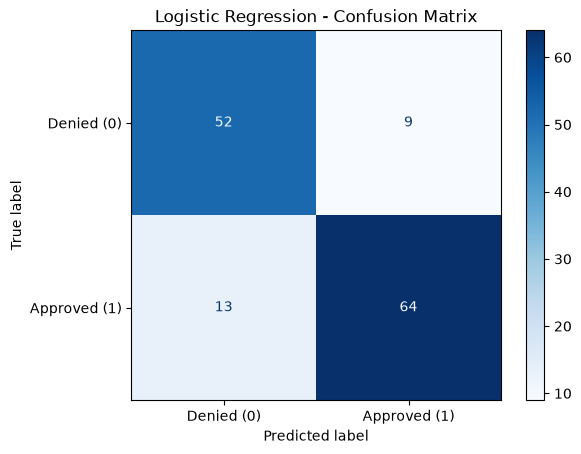

In [15]:
# Cell 14: Evaluate with two metrics — Accuracy and F1-score
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

log_accuracy = accuracy_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

print(f"Logistic Regression Accuracy: {log_accuracy:.4f}")
print(f"Logistic Regression F1-score: {log_f1:.4f}")

cm = confusion_matrix(y_test, log_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Denied (0)', 'Approved (1)'])
disp.plot(cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [16]:
# Cell 15: Build the neural network (multi-layer perceptron)
from sklearn.neural_network import MLPClassifier

# Two hidden layers (64 neurons, then 32) -> satisfies the "multi-layer" requirement
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

In [17]:
# Cell 16: Evaluate with 10-fold cross-validation
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_results = cross_validate(
    mlp_model, X, y,
    cv=cv,
    scoring=['accuracy', 'f1']
)

print(f"10-Fold CV Accuracy: {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")
print(f"10-Fold CV F1-score: {cv_results['test_f1'].mean():.4f} (+/- {cv_results['test_f1'].std():.4f})")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


10-Fold CV Accuracy: 0.8275 (+/- 0.0653)
10-Fold CV F1-score: 0.8450 (+/- 0.0602)


Neural Network Accuracy (test set): 0.8406
Neural Network F1-score (test set): 0.8571


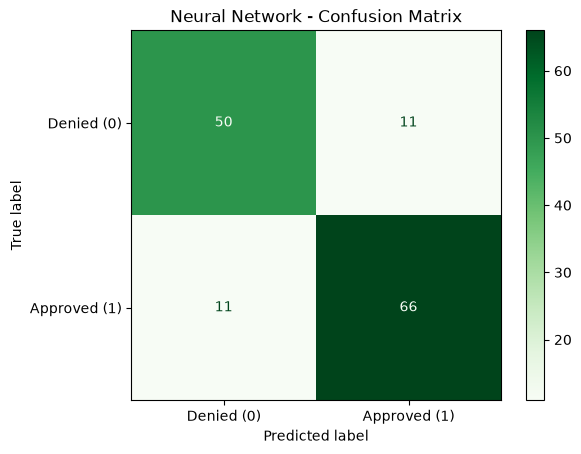

In [18]:
# Cell 17: Fit on the same train/test split (for direct comparison in Step 4d)
mlp_model.fit(X_train, y_train)
mlp_pred = mlp_model.predict(X_test)

mlp_accuracy = accuracy_score(y_test, mlp_pred)
mlp_f1 = f1_score(y_test, mlp_pred)

print(f"Neural Network Accuracy (test set): {mlp_accuracy:.4f}")
print(f"Neural Network F1-score (test set): {mlp_f1:.4f}")

cm_mlp = confusion_matrix(y_test, mlp_pred)
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=['Denied (0)', 'Approved (1)'])
disp_mlp.plot(cmap='Greens')
plt.title("Neural Network - Confusion Matrix")
plt.show()

In [19]:
# Cell 18: Define the hyperparameter grid
# Lab requires at least 3 hyperparameters from: learning rate, epochs, activation
# function, optimizer, batch size, among others.
# We use: hidden_layer_sizes, activation, and learning_rate_init.

param_grid = {
    'hidden_layer_sizes': [(32,), (64, 32), (64, 32, 16)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01, 0.1]
}

# 3 x 2 x 3 = 18 combinations, each trained across 10 folds = 180 model fits total
print("Total combinations:", 3 * 2 * 3)

Total combinations: 18


In [22]:
# Cell 19: Run Grid Search with 10-fold cross-validation
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
from sklearn.model_selection import GridSearchCV

base_mlp = MLPClassifier(solver='adam', max_iter=1000, random_state=42)

grid_search = GridSearchCV(
    estimator=base_mlp,
    param_grid=param_grid,
    cv=10,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Grid search complete.")

Grid search complete.


Best hyperparameters found:
{'activation': 'tanh', 'hidden_layer_sizes': (32,), 'learning_rate_init': 0.001}

Best cross-validated F1-score: 0.8724

Tuned Neural Network Accuracy (test set): 0.8406
Tuned Neural Network F1-score (test set): 0.8533


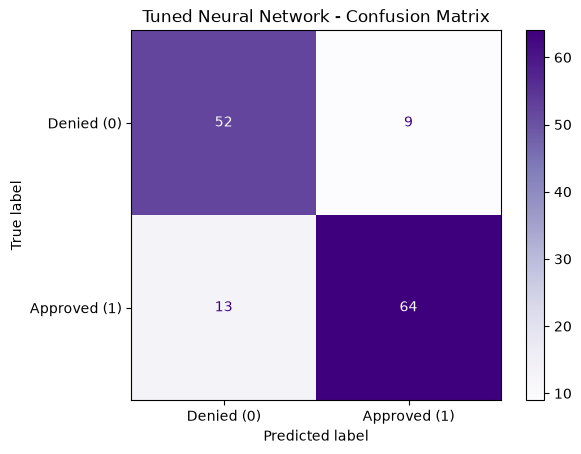

In [23]:
# Cell 20: Report the best combination and evaluate it
print("Best hyperparameters found:")
print(grid_search.best_params_)
print(f"\nBest cross-validated F1-score: {grid_search.best_score_:.4f}")

best_mlp = grid_search.best_estimator_
best_pred = best_mlp.predict(X_test)

best_accuracy = accuracy_score(y_test, best_pred)
best_f1 = f1_score(y_test, best_pred)

print(f"\nTuned Neural Network Accuracy (test set): {best_accuracy:.4f}")
print(f"Tuned Neural Network F1-score (test set): {best_f1:.4f}")

cm_best = confusion_matrix(y_test, best_pred)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['Denied (0)', 'Approved (1)'])
disp_best.plot(cmap='Purples')
plt.title("Tuned Neural Network - Confusion Matrix")
plt.show()

In [24]:
# Cell 21: Summary table of all three models
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Neural Network (untuned)', 'Neural Network (tuned)'],
    'Accuracy': [log_accuracy, mlp_accuracy, best_accuracy],
    'F1-score': [log_f1, mlp_f1, best_f1]
})

comparison_df

,Model,Accuracy,F1-score
0,Logistic Regression,0.84058,0.853333
1,Neural Network (untuned),0.84058,0.857143
2,Neural Network (tuned),0.84058,0.853333


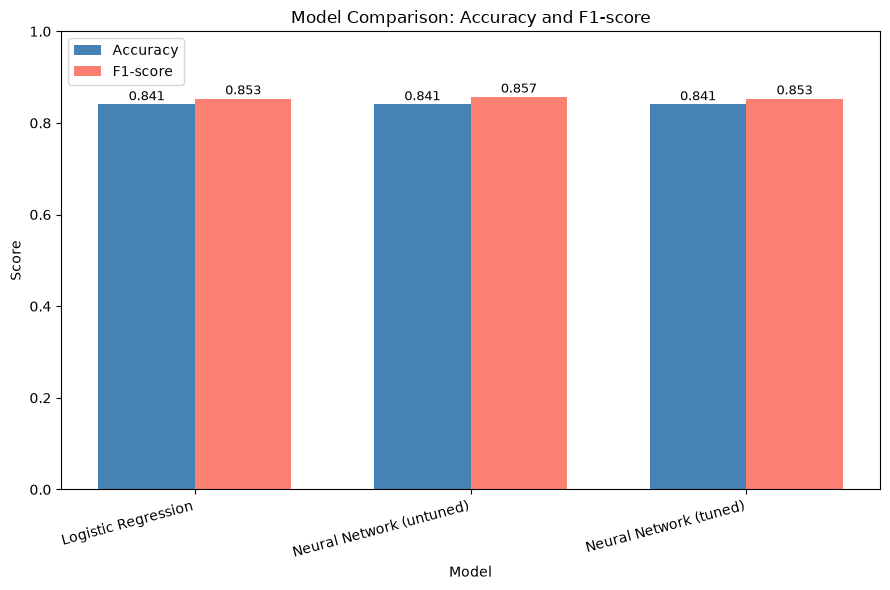

In [25]:
# Cell 22: Bar chart comparison
x = np.arange(len(comparison_df))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars1 = ax.bar(x - width/2, comparison_df['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, comparison_df['F1-score'], width, label='F1-score', color='salmon')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy and F1-score')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.legend()

# Add value labels on top of each bar for readability
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', fontsize=9)

plt.tight_layout()
plt.show()